# Phase 2 Steering

The paper's Experiment 1 (reproduction guidebook §4): extract a steering
vector from the difference between high- and low-*self-reported* trials'
own residual-stream activations at one (layer, position), inject it back in,
and measure the shift it causes in the same self-report.

This notebook fixes several gaps an earlier version of it had, all of which
made a null result uninterpretable (see `vonto/calibration/steering.py`'s
own module docstring for the full rationale):

- **Control positions, not just PANL.** Every sweep now covers all of
  `calib.POSITIONS` — `PANL` (the key, falsifying position, §4.1), `PANL+1`
  (its mandatory control — must show nothing), `FCC` (the secondary control
  inside the instructions block), and `CC` (the paper's other key position,
  later layers). Without a control, a flat PANL result can't be told apart
  from "no representation here" vs. "the whole intervention mechanism does
  nothing." AC gets its own, separate, smaller-scale functions
  (`calib.ac_steering_effect`) — it lives in a different forward pass
  entirely (the Phase-0 answer-generation prompt), so testing it means
  regenerating the answer under intervention, not a single forward pass —
  not yet wired into this notebook, see the TODO in the Summary section.
- **Both directions, always.** Every layer/position measures `+alpha*v`
  (steer high) *and* `-alpha*v` (steer low) on the same test trials — never
  just one. "Strong, bidirectional" (§4.6) is part of the actual claim.
- **Disjoint extraction/test pools**, via `calib.generate_disjoint_pools` —
  the steering vector is built from one set of trials and tested on a
  different set, matching §2.3.4's explicit disjointness requirement.
- **Extraction ranks by the observation method's own self-report**, not by a
  paired ground truth — a ground truth plays no role in the paper's steering
  experiment at all (that axis belongs to `3_heatmaps.ipynb`'s own
  cross-product sweep). An optional `correctness` ground truth restricts
  extraction to its own top (better) half (`_filter_by_gt` — a *relative*
  rank split, not a fixed `>= 0.5` threshold: `EntropyGT` is unbounded raw
  nats and `ImpurityGT` never exceeds 0.5, so a fixed threshold would
  silently keep almost everything or almost nothing for those).
- **A class-balanced test set** (`calib.select_balanced_test_trials`) rather
  than a plain random sample — checked directly against real trials here:
  Qwen's `CommitmentOM` landed in the bottom three (of ten) classes on
  **0 of 30** real candidates, so a fixed-threshold balanced split (as the
  guidebook's own §2.7 literally specifies) fails outright; this uses a
  relative top/bottom split instead, which always finds a real contrast.
- **Three metrics, not one**: confidence-midpoint delta (as before), the
  logit-difference *change* (§2.8 (1), the paper's own primary metric), and
  the first-token change rate (§2.8 (3)) — plus SEM error bars on every
  plotted point (§2.8 (6)).

Still scoped down from the paper's full grid: `LAYERS` in `config.json`'s
`steering` block can trivially be set to a dense `range` (nothing in
`run_steering_sweep` limits it to a sparse list), but `ALPHA` is still a
single value per run, not both 2 and 5 swept together in one set of plots —
that would need `run_steering_sweep` itself extended to loop alphas and plot
solid/dotted by scale, not yet done here.

Five (dataset, OM) pairs, each producing one "Δ (steered − clean) vs. layer"
plot per position, both directions overlaid:

| Dataset | OM | Correctness filter |
|---|---|---|
| `TriviaQA` | `ConfidenceOM` | `CorrectnessGT` |
| `SynonymsDataset` | `CommitmentOM` | `ProbabilityGT` |
| `SynonymsDataset` | `NuanceOM` | `EntropyGT` |
| `ListElicitationDataset` | `VarietyOM` | `ListVarianceGT` |
| `TwentyQuestionsDataset` | `ImpurityOM` | `ImpurityGT` |

The first row is the paper's own actual experiment (§4.2: confidence,
restricted to correctly-answered `TriviaQA` trials) — every other row is a
generalization to a different self-reportable construct, filtered by that
construct's own natural computed counterpart (from the sentiment-pairing
table in `2_sentiments.ipynb`) rather than literal answer-correctness, since
none of those four have a single right/wrong answer the way TriviaQA does.
The two `synonyms` pairs share the same disjoint extraction/test-candidate
split (one generation, two different self-report probes run on top of it) —
but each OM still selects its *own* balanced test subset from the shared
candidates, since "balanced" depends on that OM's own self-report values,
which differ per construct.


In [1]:
import json
import shutil
import sys
import pathlib

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from vonto import config as cfg
from vonto.models import load_model
import vonto.calibration as calib

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
print(f"config.json ({CONFIG_PATH}):", CONFIG)

STEERING_CFG = CONFIG["steering"]
N_EXTRACTION = STEERING_CFG["n_extraction"]
N_TEST_CANDIDATES = STEERING_CFG["n_test_candidates"]
N_TEST = STEERING_CFG["n_test"]
TOP_N = STEERING_CFG["top_n"]
ALPHA = STEERING_CFG["alpha"]
LAYERS = STEERING_CFG["layers"]

CACHE_DIR = CONFIG_PATH.parent / "out"
FIG_DIR = CACHE_DIR / "figures"

# Same reasoning as 3_heatmaps.ipynb: wipe the trial-generation cache on
# every run rather than risk silently serving trials generated under an
# earlier, since-fixed version of the prompt/generation code.
# shutil.rmtree(CACHE_DIR, ignore_errors=True)
# FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg.load_credentials()
loaded = load_model("qwen")
print("model loaded:", loaded.device)


config.json (/home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/notebooks_benzon/config.json): {'synonyms': {'n': 67}, 'list_elicitation': {'n': 1, 'T': 20, 'k': 20}, 'twenty_questions': {'n_games': 20, 'k': 128, 'T': 2}, 'triviaqa': {'limit': 300}, 'calibration': {'n_trials': 200}, 'steering': {'n_extraction': 60, 'n_test_candidates': 120, 'n_test': 60, 'top_n': 20, 'alpha': 5.0, 'layers': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]}}


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

model loaded: cuda:0


## Sweep helper

For one observation method and its (disjoint) extraction/test trial pools,
sweeps every position in `calib.POSITIONS` × every layer in `LAYERS`,
building a fresh steering vector at each (position, layer) and measuring
both directions' effect on the same test trials. Plots all four positions,
both directions, with SEM error bars — the shape of plot §4.5 describes,
generalized to more than one position and direction on the same axes.

In [2]:
def run_steering_sweep(triplet_tag, om, extraction_trials, test_trials, correctness=None):
    results = {}
    for position in calib.POSITIONS:
        high_mean, high_sem, low_mean, low_sem = [], [], [], []
        for layer in tqdm(LAYERS, desc=f"{triplet_tag}: {position} layer sweep"):
            r = calib.steering_effect(
                loaded, om, extraction_trials, test_trials, layer=layer, position=position,
                alpha=ALPHA, top_n=TOP_N, correctness=correctness,
            )
            high_mean.append(r["high"]["mean_delta"])
            high_sem.append(r["high"]["sem_delta"])
            low_mean.append(r["low"]["mean_delta"])
            low_sem.append(r["low"]["sem_delta"])
            print(
                f"{triplet_tag}: {position} L{layer:2d}  "
                f"high={r['high']['mean_delta']:+.4f} (rate={r['high']['change_rate']:.2f})  "
                f"low={r['low']['mean_delta']:+.4f} (rate={r['low']['change_rate']:.2f})"
            )
        results[position] = {"high_mean": high_mean, "high_sem": high_sem, "low_mean": low_mean, "low_sem": low_sem}

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.axhline(0.0, color="lightgray", linewidth=1)
    markers = {"PANL": "o", "PANL+1": "s", "FCC": "d", "CC": "^"}
    for position in calib.POSITIONS:
        r = results[position]
        ax.errorbar(LAYERS, r["high_mean"], yerr=r["high_sem"], marker=markers[position],
                    label=f"{position} (high)")
        ax.errorbar(LAYERS, r["low_mean"], yerr=r["low_sem"], marker=markers[position], linestyle="--",
                    label=f"{position} (low)")
    ax.set_xlabel("layer")
    ax.set_ylabel(f"Δ {om.name} (steered − clean)")
    ax.set_title(f"{triplet_tag}: {om.name} steering, PANL/PANL+1/FCC/CC, both directions (alpha={ALPHA})")
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / f"{triplet_tag}_delta_vs_layer.png", dpi=150, bbox_inches="tight")
    plt.show()
    return results


## Pair 0: TriviaQA — confidence

The paper's own actual experiment (§4.2): `ConfidenceOM`/`CorrectnessGT`
over `TriviaQA`, its primary dataset. Every other pair below is a
generalization *analogous* to this one, over a different self-reportable
construct and dataset — this is the one the guidebook's own §4.6 numbers
describe directly, so it's worth reproducing on its own rather than only
implicitly through the others.

### TriviaQA dataset

Same generate-always-overwrite / verify-from-cache split as the rest of this
notebook and `1_dataset.ipynb`/`3_heatmaps.ipynb`.

In [3]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import TriviaQA

triviaqa = TriviaQA(**CONFIG["triviaqa"])
triviaqa.generate()  # always regenerates -- never skipped by an existing cache
path = triviaqa.save((pathlib.Path.cwd() / "out" / "prepared"))
print(f"triviaqa: generated + saved {len(triviaqa.seeds)} seeds -> {path} (overwritten)")


triviaqa: generated + saved 300 seeds -> /scratch/qi/project/data/prepared/TriviaQA_limit300.json (overwritten)


In [4]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import TriviaQA

triviaqa = TriviaQA(**CONFIG["triviaqa"])
assert triviaqa.load_if_cached((pathlib.Path.cwd() / "out" / "prepared")), (
    f"no cache found for {triviaqa.shape_tag()} -- run the generation cell above first"
)
print(f"triviaqa: loaded {len(triviaqa.seeds)} seeds from cache ({triviaqa.shape_tag()}.json)")


triviaqa: loaded 300 seeds from cache (TriviaQA_limit300.json)


TriviaQA_limit300: generating extraction trials:   0%|          | 0/60 [00:00<?, ?it/s]

TriviaQA_limit300: generating test trials:   0%|          | 0/120 [00:00<?, ?it/s]

confidence: classifying candidates for balanced sampling:   0%|          | 0/120 [00:00<?, ?it/s]

triviaqa_confidence: PANL layer sweep:   0%|          | 0/28 [00:00<?, ?it/s]

confidence: ranking extraction pool:   0%|          | 0/30 [00:00<?, ?it/s]

...

triviaqa_confidence: CC L26  high=+0.0500 (rate=0.22)  low=-0.0683 (rate=0.38)


confidence: ranking extraction pool:   0%|          | 0/30 [00:00<?, ?it/s]

confidence: capturing CC activations @ L27:   0%|          | 0/30 [00:00<?, ?it/s]

confidence: CC steering @ L27:   0%|          | 0/60 [00:00<?, ?it/s]

triviaqa_confidence: CC L27  high=+0.0383 (rate=0.15)  low=-0.0450 (rate=0.30)


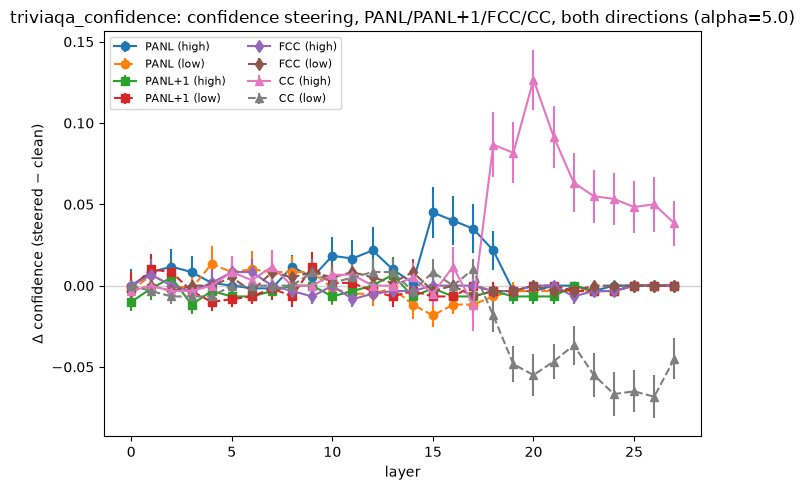

In [5]:
from vonto.observation_method import ConfidenceOM
from vonto.ground_truth import CorrectnessGT

confidence_om = ConfidenceOM()
# sentiment_om=confidence_om: this is the one pair actually replicating the
# paper's own confidence experiment, so Phase 0 front-loads ConfidenceOM's
# instructions here, matching the paper's design (generation.py) -- every
# other pair below leaves Phase 0 construct-agnostic (no confidence priming).
triviaqa_extraction, triviaqa_test_candidates = calib.generate_disjoint_pools(
    loaded, triviaqa, N_EXTRACTION, N_TEST_CANDIDATES, CACHE_DIR, rng_seed=0, sentiment_om=confidence_om,
)
confidence_test = calib.select_balanced_test_trials(loaded, confidence_om, triviaqa_test_candidates, N_TEST)
confidence_results = run_steering_sweep(
    "triviaqa_confidence", confidence_om, triviaqa_extraction, confidence_test, correctness=CorrectnessGT(),
)


## Triplets 1 & 2: Synonyms — commitment, then nuance

One shared disjoint extraction/test-candidate split, two self-report probes
run on top of it — each with its own correctness-filtered extraction and its
own balanced test subset (see the intro).

### Synonyms dataset

Same generate-always-overwrite / verify-from-cache split as `1_dataset.ipynb`
and `3_heatmaps.ipynb`: a self-contained generation cell followed by a
self-contained verification cell, so either runs standalone.

In [19]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import SynonymsDataset, download_word2vec_vectors

word2vec_path = download_word2vec_vectors()
synonyms = SynonymsDataset(word2vec_path, **CONFIG["synonyms"])
synonyms.generate()  # always regenerates -- never skipped by an existing cache
path = synonyms.save((pathlib.Path.cwd() / "out" / "prepared"))
print(f"synonyms: generated + saved {len(synonyms.seeds)} seeds -> {path} (overwritten)")


[SynonymsDataset] dropped 378/879 'Synonym'-labeled pairs below word2vec similarity 0.25 (not genuinely interchangeable)
synonyms: generated + saved 201 seeds -> /scratch/qi/project/data/prepared/Synonyms_n67.json (overwritten)


In [20]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import SynonymsDataset

synonyms = SynonymsDataset(None, **CONFIG["synonyms"])  # word2vec_path unused on the load-from-cache path
assert synonyms.load_if_cached((pathlib.Path.cwd() / "out" / "prepared")), (
    f"no cache found for {synonyms.shape_tag()} -- run the generation cell above first"
)
print(f"synonyms: loaded {len(synonyms.seeds)} seeds from cache ({synonyms.shape_tag()}.json)")


synonyms: loaded 201 seeds from cache (Synonyms_n67.json)


### Disjoint extraction/test-candidate pools (shared by both synonyms triplets)

In [21]:
synonyms_extraction, synonyms_test_candidates = calib.generate_disjoint_pools(
    loaded, synonyms, N_EXTRACTION, N_TEST_CANDIDATES, CACHE_DIR, rng_seed=0,
)
print(f"synonyms: {len(synonyms_extraction)} extraction trials, {len(synonyms_test_candidates)} test candidates")


Synonyms_n67: generating extraction trials:   0%|          | 0/60 [00:00<?, ?it/s]

Synonyms_n67: generating test trials:   0%|          | 0/120 [00:00<?, ?it/s]

synonyms: 60 extraction trials, 120 test candidates


### Commitment × probability-filtered extraction

Filtered by `ProbabilityGT` (the natural sentiment-paired counterpart of
`CommitmentOM`, `2_sentiments.ipynb`) rather than literal correctness —
restricts extraction to the top (better) half of `synonyms_extraction` by
that GT's own value, see `_filter_by_gt`.

commitment: classifying candidates for balanced sampling:   0%|          | 0/120 [00:00<?, ?it/s]

synonyms_commitment: PANL layer sweep:   0%|          | 0/28 [00:00<?, ?it/s]

commitment: ranking extraction pool:   0%|          | 0/30 [00:00<?, ?it/s]

commitment: capturing PANL activations @ L0:   0%|          | 0/30 [00:00<?, ?it/s]

commitment: PANL steering @ L0:   0%|          | 0/60 [00:00<?, ?it/s]

...

synonyms_commitment: CC L26  high=+0.0750 (rate=0.25)  low=-0.1500 (rate=0.50)


commitment: ranking extraction pool:   0%|          | 0/30 [00:00<?, ?it/s]

commitment: capturing CC activations @ L27:   0%|          | 0/30 [00:00<?, ?it/s]

commitment: CC steering @ L27:   0%|          | 0/60 [00:00<?, ?it/s]

synonyms_commitment: CC L27  high=+0.0517 (rate=0.18)  low=-0.1350 (rate=0.45)


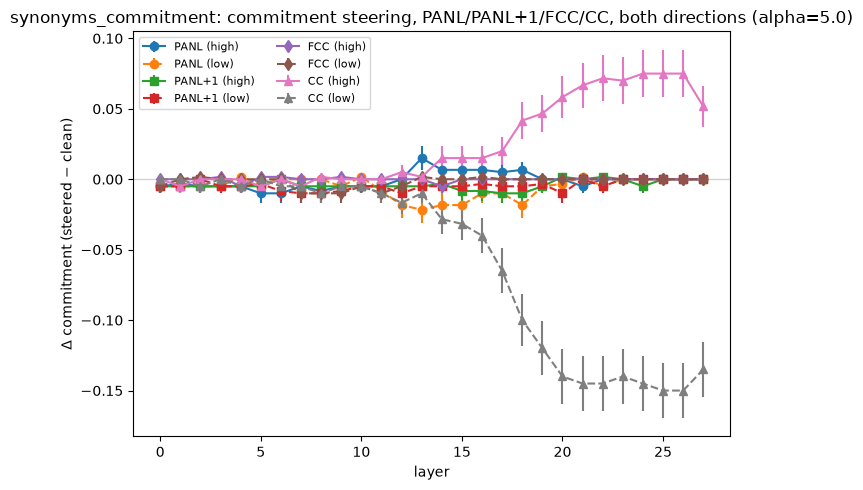

In [22]:
from vonto.observation_method import CommitmentOM
from vonto.ground_truth import ProbabilityGT

commitment_om = CommitmentOM()
commitment_test = calib.select_balanced_test_trials(loaded, commitment_om, synonyms_test_candidates, N_TEST)
commitment_results = run_steering_sweep(
    "synonyms_commitment", commitment_om, synonyms_extraction, commitment_test, correctness=ProbabilityGT(),
)


### Nuance × entropy-filtered extraction

Filtered by `EntropyGT` (`NuanceOM`'s own sentiment-paired counterpart) —
top (better) half of `synonyms_extraction` by entropy.

nuance: classifying candidates for balanced sampling:   0%|          | 0/120 [00:00<?, ?it/s]

synonyms_nuance: PANL layer sweep:   0%|          | 0/28 [00:00<?, ?it/s]

nuance: ranking extraction pool:   0%|          | 0/30 [00:00<?, ?it/s]

nuance: capturing PANL activations @ L0:   0%|          | 0/30 [00:00<?, ?it/s]

nuance: PANL steering @ L0:   0%|          | 0/60 [00:00<?, ?it/s]

...

synonyms_nuance: CC L26  high=-0.0017 (rate=0.52)  low=-0.0200 (rate=0.05)


nuance: ranking extraction pool:   0%|          | 0/30 [00:00<?, ?it/s]

nuance: capturing CC activations @ L27:   0%|          | 0/30 [00:00<?, ?it/s]

nuance: CC steering @ L27:   0%|          | 0/60 [00:00<?, ?it/s]

synonyms_nuance: CC L27  high=+0.0017 (rate=0.52)  low=-0.0133 (rate=0.03)


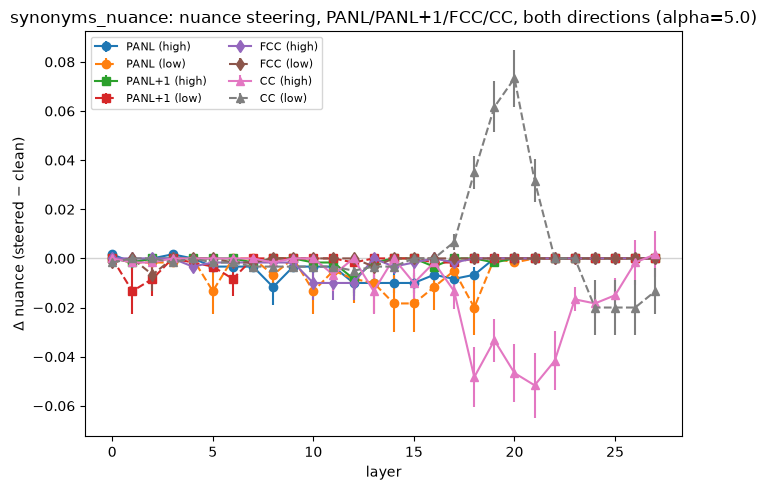

In [23]:
from vonto.observation_method import NuanceOM
from vonto.ground_truth import EntropyGT

nuance_om = NuanceOM()
nuance_test = calib.select_balanced_test_trials(loaded, nuance_om, synonyms_test_candidates, N_TEST)
nuance_results = run_steering_sweep(
    "synonyms_nuance", nuance_om, synonyms_extraction, nuance_test, correctness=EntropyGT(),
)


## Triplet 3: List elicitation — variety

Filtered by `ListVarianceGT` (`VarietyOM`'s own sentiment-paired
counterpart) rather than answer-correctness — `ListElicitationDataset` has
no single right/wrong answer, but does have its own natural computed
counterpart to restrict extraction by.

In [24]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import ListElicitationDataset

list_elicitation = ListElicitationDataset(**CONFIG["list_elicitation"])
list_elicitation.generate()  # always regenerates -- never skipped by an existing cache
path = list_elicitation.save((pathlib.Path.cwd() / "out" / "prepared"))
print(f"list_elicitation: generated + saved {len(list_elicitation.seeds)} seeds -> {path} (overwritten)")


list_elicitation: generated + saved 200 seeds -> /scratch/qi/project/data/prepared/ListElicitation_n1k20T20.json (overwritten)


In [3]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import ListElicitationDataset

list_elicitation = ListElicitationDataset(**CONFIG["list_elicitation"])
assert list_elicitation.load_if_cached((pathlib.Path.cwd() / "out" / "prepared")), (
    f"no cache found for {list_elicitation.shape_tag()} -- run the generation cell above first"
)
print(f"list_elicitation: loaded {len(list_elicitation.seeds)} seeds from cache "
      f"({list_elicitation.shape_tag()}.json)")


list_elicitation: loaded 200 seeds from cache (ListElicitation_n1k20T20.json)


variety: classifying candidates for balanced sampling:   0%|          | 0/120 [00:00<?, ?it/s]

list_variety: PANL layer sweep:   0%|          | 0/28 [00:00<?, ?it/s]

variety: ranking extraction pool:   0%|          | 0/30 [00:00<?, ?it/s]

variety: capturing PANL activations @ L0:   0%|          | 0/30 [00:00<?, ?it/s]

variety: PANL steering @ L0:   0%|          | 0/60 [00:00<?, ?it/s]

...

list_variety: CC L26  high=+0.0467 (rate=0.23)  low=-0.0667 (rate=0.20)


variety: ranking extraction pool:   0%|          | 0/30 [00:00<?, ?it/s]

variety: capturing CC activations @ L27:   0%|          | 0/30 [00:00<?, ?it/s]

variety: CC steering @ L27:   0%|          | 0/60 [00:00<?, ?it/s]

list_variety: CC L27  high=+0.0450 (rate=0.22)  low=-0.0500 (rate=0.18)


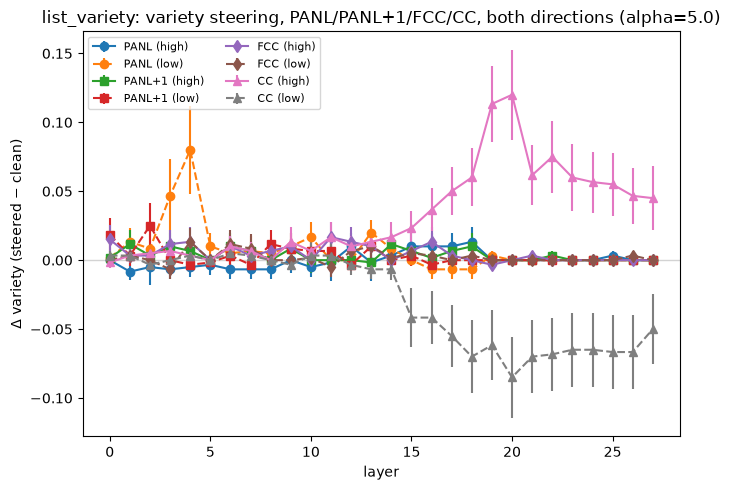

In [4]:
from vonto.observation_method import VarietyOM
from vonto.ground_truth import ListVarianceGT

list_extraction, list_test_candidates = calib.generate_disjoint_pools(
    loaded, list_elicitation, N_EXTRACTION, N_TEST_CANDIDATES, CACHE_DIR, rng_seed=0,
)
variety_om = VarietyOM()
variety_test = calib.select_balanced_test_trials(loaded, variety_om, list_test_candidates, N_TEST)
variety_results = run_steering_sweep(
    "list_variety", variety_om, list_extraction, variety_test, correctness=ListVarianceGT(),
)


## Triplet 4: Twenty questions — impurity

Filtered by `ImpurityGT` (`ImpurityOM`'s own sentiment-paired counterpart)
— needs the loaded model bound at construction (classifying candidates
under the model's own proposed question is itself a model call).

In [26]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import TwentyQuestionsDataset

if "loaded" not in globals():
    from vonto.models import load_model
    cfg.load_credentials()
    loaded = load_model("qwen")  # only reached when this cell is run standalone

twenty_questions = TwentyQuestionsDataset(
    loaded, **CONFIG["twenty_questions"],
    checkpoint_path=(pathlib.Path.cwd() / "out" / "prepared") / "twenty_questions_checkpoint.json",
)
twenty_questions.generate()  # always called -- resumes from its own mid-game checkpoint
path = twenty_questions.save((pathlib.Path.cwd() / "out" / "prepared"))
print(f"twenty_questions: generated + saved {len(twenty_questions.seeds)} seeds -> {path} (overwritten)")


[TwentyQuestionsDataset] loaded 200 already-played games from checkpoint
twenty_questions: generated + saved 200 seeds -> /scratch/qi/project/data/prepared/TwentyQuestions_n_games20k128T2.json (overwritten)


In [27]:
import json, pathlib, sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vonto").is_dir())
sys.path.insert(0, str(ROOT))

from vonto import config as cfg

CONFIG_PATH = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.json").exists()) / "config.json"
CONFIG = json.loads(CONFIG_PATH.read_text())
from vonto.dataset import TwentyQuestionsDataset

twenty_questions = TwentyQuestionsDataset(
    None, **CONFIG["twenty_questions"],  # loaded model unused on the load-from-cache path
    checkpoint_path=(pathlib.Path.cwd() / "out" / "prepared") / "twenty_questions_checkpoint.json",
)
assert twenty_questions.load_if_cached((pathlib.Path.cwd() / "out" / "prepared")), (
    f"no cache found for {twenty_questions.shape_tag()} -- run the generation cell above first"
)
print(f"twenty_questions: loaded {len(twenty_questions.seeds)} seeds from cache "
      f"({twenty_questions.shape_tag()}.json)")


twenty_questions: loaded 200 seeds from cache (TwentyQuestions_n_games20k128T2.json)


In [28]:
from vonto.observation_method import ImpurityOM
from vonto.ground_truth import ImpurityGT

twentyq_extraction, twentyq_test_candidates = calib.generate_disjoint_pools(
    loaded, twenty_questions, N_EXTRACTION, N_TEST_CANDIDATES, CACHE_DIR, rng_seed=0,
)
impurity_om = ImpurityOM()
impurity_test = calib.select_balanced_test_trials(loaded, impurity_om, twentyq_test_candidates, N_TEST)
impurity_results = run_steering_sweep(
    "twentyq_impurity", impurity_om, twentyq_extraction, impurity_test, correctness=ImpurityGT(loaded),
)


TwentyQuestions_n_games20k128T2: generating extraction trials:   0%|          | 0/60 [00:00<?, ?it/s]

TwentyQuestions_n_games20k128T2: generating test trials:   0%|          | 0/120 [00:00<?, ?it/s]

impurity: classifying candidates for balanced sampling:   0%|          | 0/120 [00:00<?, ?it/s]

ValueError: impurity: every one of 120 candidates landed on the same self-report value (0.65) -- no low/high contrast to build a balanced test set from

## Summary

The headline comparison — PANL, high-direction only, all five pairs
overlaid — mirrors the paper's own §4.6 summary figure most directly. The
full per-pair breakdown (all 4 positions × both directions × SEM) is each
pair's own plot above; this is deliberately the single reduced view, not a
replacement for those.

A genuine null (curve hovering near zero everywhere, at every position —
*including* PANL+1/FCC, which should be null anyway) is as real a result as
a peak somewhere; a PANL curve that looks just like its own PANL+1/FCC
controls is the actually informative "no effect here" reading now, since
earlier versions of this notebook had no control to compare against at all.

**TODO, not yet wired in here**: `calib.ac_steering_effect` (the AC control
— regenerates the answer under intervention rather than a single forward
pass, so deliberately kept out of `run_steering_sweep`'s dense per-layer
loop; see its own docstring) and a dual-alpha (2 and 5 together, solid vs.
dotted) version of `run_steering_sweep`.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.axhline(0.0, color="lightgray", linewidth=1)
for label, results in [
    ("confidence (triviaqa)", confidence_results),
    ("commitment (synonyms)", commitment_results),
    ("nuance (synonyms)", nuance_results),
    ("variety (list)", variety_results),
    ("impurity (twentyq)", impurity_results),
]:
    r = results["PANL"]
    ax.errorbar(LAYERS, r["high_mean"], yerr=r["high_sem"], marker="o", label=label)
ax.set_xlabel("layer")
ax.set_ylabel("Δ self-report midpoint (steered − clean)")
ax.set_title(f"All five pairs: PANL high-direction steering (alpha={ALPHA})")
ax.legend()
fig.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "all_pairs_panl_high_delta_vs_layer.png", dpi=150, bbox_inches="tight")
plt.show()
